In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path

TARGET_CRS = "EPSG:5070"

In [30]:
# Census Codes

census_codes = {
    "GEO_ID": "GEOID",
    "B02001_001E": "Race",
    "B03002_003E": "White alone, non-Hispanic",
    "B03002_004E": "Black alone, non-Hispanic",
    "B03002_012E": "Hispanic or Latino",
    "B03002_005E": "American Indian and Alaska Native Alone, non-Hispanic",
    "B03002_006E": "Asian Alone, non-Hispanic",
    "B03002_007E": "Native Hawaiian and Other Pacific Islander Alone, non-Hispanic",
    "B15003_020E": "Some college, 1 or more years, no degree", # not in ACS 2010
    "B15003_021E": "Associate's degree",
    "B15003_022E": "Bachelor's degree",
    "B15003_023E": "Master's degree",
    "B15003_024E": "Professional school degree",
    "B15003_025E": "Doctorate degree",
    "B19013_001E": "Median Household Income",
    "B17001_002E": "Income in the past 12 months below poverty level",
    "B25064_001E": "Median Gross Rent",
    "B05001_002E": "Native, Total Population",
    "B05001_004E": "Foreign born, Naturalized U.S. Citizen",
    "B25034_001E": "Total Structures",
    "B25034_002E": "Built 2020s",
    "B25034_003E": "Built 2010s",
    "B25034_004E": "Built 2000s",
    "B25034_005E": "Built 1990s",
    "B25034_006E": "Built 1980s",
    "B25034_007E": "Built 1970s",
    "B25034_008E": "Built 1960s",
    "B25034_009E": "Built 1950s",
    "B25034_010E": "Built 1940s",
    "B25034_011E": "Built Before 1940",
    "B27001_002E": "Male, Health insurance Coverage",
    "B27001_018E": "Female, Health insurance Coverage",
    "B25003_001E": "Occupied Housing Units",
    "B25003_003E": "Renter occupied",
    "B25003_002E": "Owner occupied",
    "B08303_002E": "Travel Time, less than 5 minutes",
    "B08303_003E": "Travel Time, 5-9 minutes",
    "B08303_004E": "Travel Time, 10-14 minutes",
    "B08303_005E": "Travel Time, 15-19 minutes",
    "B08303_006E": "Travel Time, 20-24 minutes",
    "B08303_007E": "Travel Time, 25-29 minutes",
    "B08303_008E": "Travel Time, 30-34 minutes",
    "B08303_009E": "Travel Time, 35-39 minutes",
    "B08303_010E": "Travel Time, 40-44 minutes",
    "B08303_011E": "Travel Time, 45-59 minutes",
    "B08303_012E": "Travel Time, 60-89 minutes",
    "B08303_013E": "Travel Time, 90 minutes or more",
    "B08301_003E": "Car, truck, or van, Drove Alone",
    "B08301_004E": "Car, truck, or van, Carpool",
    "B08301_011E": "Public transportation, Bus",
    "B08301_012E": "Public transportation, Light Rail",
    "B08301_013E": "Public transportation, Hard Rail",
    "B23025_002E": "Labor force",
    "B23025_005E": "Unemployed persons",
    "B23025_007E": "Not in labor force",
    "B16001_001E": "Language at home, Total",
    "B16001_002E": "Language at home, only English",
    "B16001_003E": "Language at home, Spanish",
    "B21001_002E": "Veteran",
    "B11005_001E": "Households",
    "B11005_002E": "Households with one or more people under 18 years",
    "B01001_003E": "Male, Under 5",
    "B01001_004E": "Male, 5 to 9 years",
    "B01001_005E": "Male, 10 to 14 years",
    "B01001_006E": "Male, 15 to 17 years",
    "B01001_007E": "Male, 18 to 19 years",
    "B01001_008E": "Male, 20 years",
    "B01001_009E": "Male, 21 years",
    "B01001_010E": "Male, 22 to 24 years",
    "B01001_011E": "Male, 25 to 29 years",
    "B01001_012E": "Male, 30 to 34 years",
    "B01001_013E": "Male, 35 to 39 years",
    "B01001_014E": "Male, 40 to 44 years",
    "B01001_015E": "Male, 45 to 49 years",
    "B01001_016E": "Male, 50 to 54 years",
    "B01001_017E": "Male, 55 to 59 years",
    "B01001_018E": "Male, 60 and 61 years",
    "B01001_019E": "Male, 62 to 64 years",
    "B01001_020E": "Male, 65 and 66 years",
    "B01001_021E": "Male, 67 to 69 years",
    "B01001_022E": "Male, 70 to 74 years",
    "B01001_023E": "Male, 75 to 79 years",
    "B01001_024E": "Male, 80 to 84 years",
    "B01001_025E": "Male, 85 years and over",
    "B01001_027E": "Female, Under 5",
    "B01001_028E": "Female, 5 to 9 years",
    "B01001_029E": "Female, 10 to 14 years",
    "B01001_030E": "Female, 15 to 17 years",
    "B01001_031E": "Female, 18 to 19 years",
    "B01001_032E": "Female, 20 years",
    "B01001_033E": "Female, 21 years",
    "B01001_034E": "Female, 22 to 24 years",
    "B01001_035E": "Female, 25 to 29 years",
    "B01001_036E": "Female, 30 to 34 years",
    "B01001_037E": "Female, 35 to 39 years",
    "B01001_038E": "Female, 40 to 44 years",
    "B01001_039E": "Female, 45 to 49 years",
    "B01001_040E": "Female, 50 to 54 years",
    "B01001_041E": "Female, 55 to 59 years",
    "B01001_042E": "Female, 60 and 61 years",
    "B01001_043E": "Female, 62 to 64 years",
    "B01001_044E": "Female, 65 and 66 years",
    "B01001_045E": "Female, 67 to 69 years",
    "B01001_046E": "Female, 70 to 74 years",
    "B01001_047E": "Female, 75 to 79 years",
    "B01001_048E": "Female, 80 to 84 years",
    "B01001_049E": "Female, 85 years and over",
}


In [31]:
CODES = {
    value: key
    for key, value in census_codes.items()
}

In [14]:
folder = Path("./census")

IllinoisCensus = {}

for file in folder.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        IllinoisCensus[file.name] = pd.read_csv(file)

In [2]:
ILTracts2020 = gpd.read_file('./maps/raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp').to_crs(TARGET_CRS)
ILRoads2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_prisecroads/tl_2025_17_prisecroads.shp').to_crs(TARGET_CRS)
ILPlaces2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_place/tl_2025_17_place.shp').to_crs(TARGET_CRS)
ILTollways2025 = gpd.read_file("./maps/raw/IL/TollwayReferenceLines.gdb").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ChicagoCommunityAreas = gpd.read_file("./maps/raw/Chicago/ChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(
c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'TollwayReferenceLines.gdb': 'NewReferenceLine' (default), 'ReferenceLine'. Specify layer parameter to avoid this warning.
  result = read_func(


In [3]:
# ILPlaces2025_WithChicagoCommunityAreas

ILPlaces2025_WithChicagoCommunityAreas = gpd.GeoDataFrame(
    pd.concat(
        [ILPlaces2025, ChicagoCommunityAreas],
        ignore_index=True
    ),
    geometry="geometry",
    crs=ILPlaces2025.crs
)

ILPlaces2025_WithChicagoCommunityAreas = ILPlaces2025_WithChicagoCommunityAreas[(
    (ILPlaces2025_WithChicagoCommunityAreas['NAME'] != 'Chicago')
)]

In [27]:


[
    column
    for column in IllinoisCensus['IL_2020_ACS5_place_data.csv'].columns
    if column.endswith(("_x", "_y"))
]

IllinoisCensus['IL_2020_ACS5_place_data.csv'] = (
    IllinoisCensus['IL_2020_ACS5_place_data.csv']
    .drop(
        columns="NAME_y",
        errors="ignore",
    )
    .rename(
        columns={
            "NAME_x": "NAME",
        }
    )
)


In [28]:
MergeWith2025ACS_ILPlaces2025_WithChicagoCommunityAreas = ILPlaces2025_WithChicagoCommunityAreas.merge(
    IllinoisCensus['IL_2020_ACS5_place_data.csv'],
    how="left",
    left_on="GEOIDFQ",
    right_on="GEO_ID",
)

In [41]:
def ZoomToTheExtentOf(ax, geoDataFrame):
    minx, miny, maxx, maxy = geoDataFrame.total_bounds

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    return ax

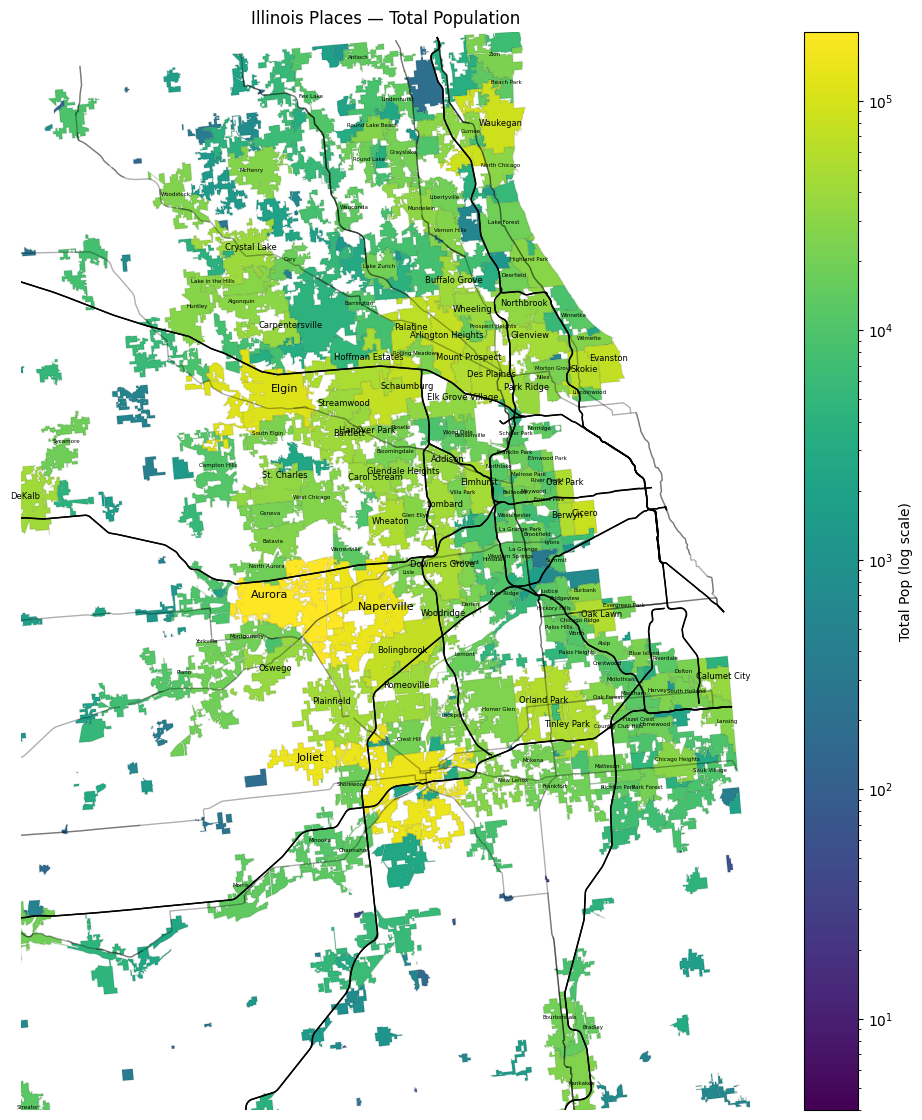

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

column = CODES['Race']

# Log scales cannot contain zero or negative values
plot_data = MergeWith2025ACS_ILPlaces2025_WithChicagoCommunityAreas[
    MergeWith2025ACS_ILPlaces2025_WithChicagoCommunityAreas[column] > 0
].copy()

fig, ax = plt.subplots(figsize=(14, 14))

plot_data.plot(
    column=column,
    ax=ax,
    legend=True,
    norm=LogNorm(
        vmin=plot_data[column].min(),
        vmax=plot_data[column].max(),
    ),
    legend_kwds={
        "label": "Total Pop (log scale)",
    },
    edgecolor='#00000015'
)

ILRoads2025[(
    ILRoads2025['RTTYP'] == 'I'
)].plot(
    ax=ax,
    linewidth=1,
    edgecolor='#000'
)

ILRoads2025[(
    ILRoads2025['RTTYP'] == 'U'
)].plot(
    ax=ax,
    linewidth=1,
    edgecolor='#00000050'
)

# Label only places with Race > 10^4
label_data = plot_data[
    plot_data[column] > 10**4
]
for _, row in label_data.iterrows():
    point = row.geometry.representative_point()
    if row[column] > 10**5:
        ax.annotate(
            text=row["NAME_x"],
            xy=(point.x, point.y),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )
        continue

    elif row[column] > 10**4.5:
         ax.annotate(
            text=row["NAME_x"],
            xy=(point.x, point.y),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=6
        )

    elif row[column] > 10**4:
         ax.annotate(
            text=row["NAME_x"],
            xy=(point.x, point.y),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=4
        )

    

ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")

ZoomToTheExtentOf(ax, ILCollarCountiesArea)


plt.show()